# Electro-Optic Modulator (EOM) Sideband Analysis — 620 nm Laser

## Theory

A phase electro-optic modulator driven at RF frequency $\Omega$ imprints a sinusoidal phase on the carrier field:

$$E_{\text{out}}(t) = E_0 \, e^{i(\omega_0 t + \beta \sin \Omega t)}$$

where $\omega_0 = 2\pi c / \lambda$ is the optical carrier frequency and $\beta$ is the **modulation index** (modulation depth in radians).

Using the **Jacobi–Anger expansion** this becomes:

$$E_{\text{out}}(t) = E_0 \sum_{n=-\infty}^{\infty} J_n(\beta) \, e^{i(\omega_0 + n\Omega) t}$$

so discrete **sidebands** appear at $\omega_0 + n\Omega$ with **amplitude** $\propto J_n(\beta)$ and **power** $\propto J_n^2(\beta)$.

### Modulation index and $V_\pi$ (phase EOM)

The phase shift is $\phi = \pi V / V_\pi$, so with $V = V_{\text{RF}}\sin\Omega t$ we get $\beta = \pi V_{\text{RF}}/V_\pi = \pi V_{\text{pp}}/(2V_\pi)$. Hence:
$$V_{\text{pp}} = \frac{2\,V_\pi\,\beta}{\pi}$$

### Two-frequency modulation

When the EOM is simultaneously driven at $\Omega_1$ and $\Omega_2$:

$$E_{\text{out}}(t) = E_0 \, e^{i[\omega_0 t + \beta_1 \sin \Omega_1 t + \beta_2 \sin \Omega_2 t]}$$

$$= E_0 \sum_{n,m} J_n(\beta_1)\, J_m(\beta_2)\, e^{i(\omega_0 + n\Omega_1 + m\Omega_2) t}$$

Sidebands now form a **2-D grid** at frequencies $\omega_0 + n\Omega_1 + m\Omega_2$.

In [6]:
import numpy as np
from scipy.special import jv as besselJ
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

# ── Physical constants & laser parameters ──
c = 2.998e8          # m/s
lam = 620e-9         # 620 nm
nu_carrier = c / lam # optical carrier frequency (Hz)

print(f"Carrier wavelength : {lam*1e9:.0f} nm")
print(f"Carrier frequency  : {nu_carrier/1e12:.3f} THz")

Carrier wavelength : 620 nm
Carrier frequency  : 483.548 THz


## 1. Single-frequency modulation

Vary the modulation index $\beta$ and see how the Bessel-function sidebands redistribute the carrier power.

TypeError: 'LineCollection' object is not iterable

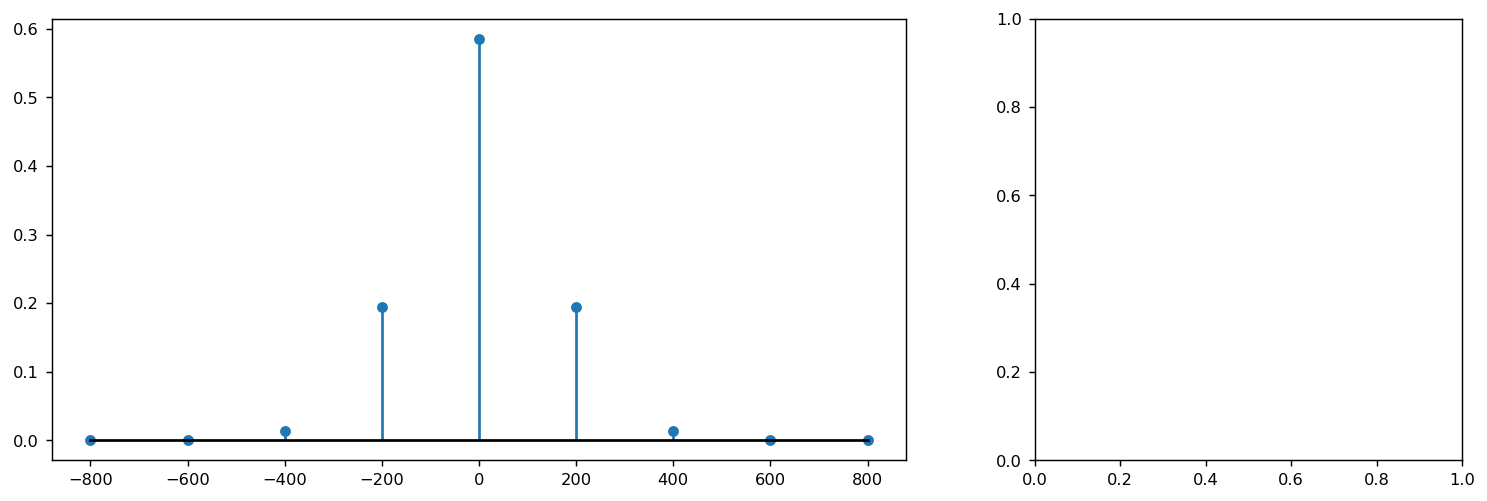

In [7]:
def plot_single_freq_spectrum(Omega_MHz, beta, n_max=10, power_floor_dB=-60):
    """
    Plot the optical spectrum of a phase-modulated carrier.

    Parameters
    ----------
    Omega_MHz : float   – RF drive frequency in MHz
    beta      : float   – modulation index (rad)
    n_max     : int     – highest sideband order to include (±n_max)
    power_floor_dB : float – hide sidebands below this relative power
    """
    orders = np.arange(-n_max, n_max + 1)
    amplitudes = besselJ(orders, beta)
    powers = amplitudes ** 2                    # relative power |J_n(β)|²

    freqs_offset_MHz = orders * Omega_MHz       # offset from carrier (MHz)

    mask = 10 * np.log10(np.maximum(powers, 1e-30)) >= power_floor_dB
    orders_show = orders[mask]
    freqs_show = freqs_offset_MHz[mask]
    powers_show = powers[mask]

    # ── Figure ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5),
                                    gridspec_kw={"width_ratios": [2, 1]})

    # Left: stem spectrum
    colors = ["#d62728" if n == 0 else "#1f77b4" for n in orders_show]
    markerline, stemlines, baseline = ax1.stem(freqs_show, powers_show,
                                                linefmt="-", markerfmt="o",
                                                basefmt="k-")
    markerline.set_markersize(5)
    stemlines.set_colors(colors)
    markerline.set_color("#1f77b4")

    ax1.set_xlabel("Frequency offset from carrier  (MHz)")
    ax1.set_ylabel(r"Relative power  $|J_n(\beta)|^2$")
    ax1.set_title(rf"Single-tone EOM spectrum   $\Omega / 2\pi = {Omega_MHz}$ MHz,  $\beta = {beta:.2f}$ rad")
    ax1.set_ylim(bottom=0)
    ax1.axhline(0, color="k", lw=0.5)

    for n, f, p in zip(orders_show, freqs_show, powers_show):
        if p > 0.005:
            ax1.annotate(f"n={n}\n{p:.3f}", (f, p), textcoords="offset points",
                         xytext=(0, 8), ha="center", fontsize=7)

    # Right: table of significant sidebands
    table_data = []
    for n, f, p in zip(orders_show, freqs_show, powers_show):
        wl_nm = c / (nu_carrier + f * 1e6) * 1e9
        table_data.append([
            f"{n:+d}",
            f"{f:+.1f}",
            f"{wl_nm:.6f}",
            f"{p:.5f}",
            f"{10*np.log10(max(p,1e-30)):+.1f}",
        ])
    col_labels = ["Order n", "Δf (MHz)", "λ (nm)", "Rel. power", "dB"]
    ax2.axis("off")
    tbl = ax2.table(cellText=table_data, colLabels=col_labels,
                    loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.25)
    ax2.set_title("Sideband details", pad=12)

    fig.tight_layout()
    plt.show()

    total_power = np.sum(powers_show)
    print(f"Visible sidebands (>{power_floor_dB} dB): {len(orders_show)}  "
          f"(orders {orders_show[0]:+d} … {orders_show[-1]:+d})")
    print(f"Total power in visible sidebands: {total_power:.5f}  "
          f"(should be ~1.0 by Bessel identity)")


# ── Example: moderate modulation ──
plot_single_freq_spectrum(Omega_MHz=200, beta=1.0)

TypeError: 'LineCollection' object is not iterable

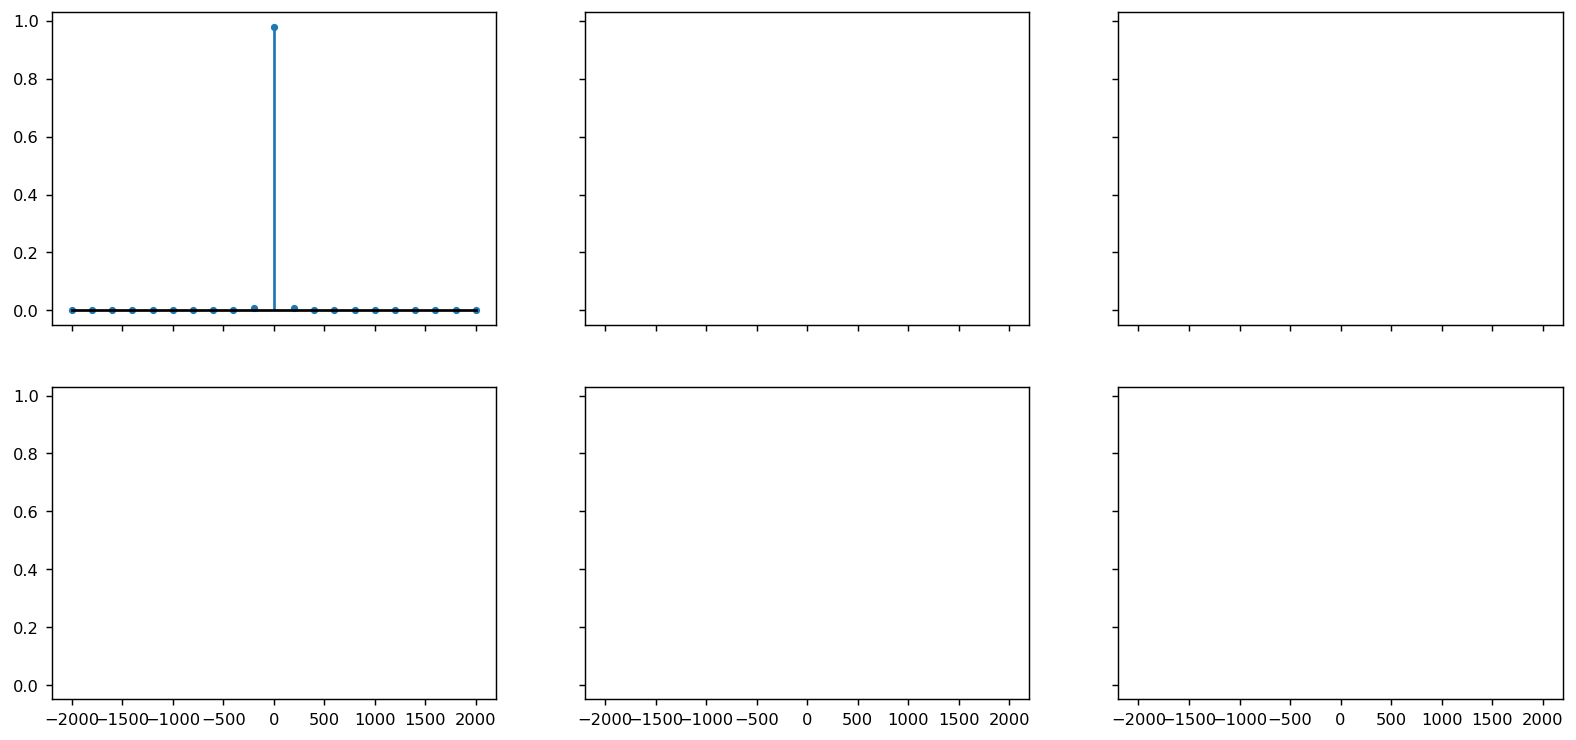

In [ ]:
# ── Sweep β to see how sidebands evolve ──
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
betas = [0.2, 0.5, 1.0, 1.5, 2.4, 3.8]
Omega_MHz = 200
n_max = 10
orders = np.arange(-n_max, n_max + 1)

for ax, beta in zip(axes.flat, betas):
    powers = besselJ(orders, beta) ** 2
    freqs = orders * Omega_MHz
    colors = ["#d62728" if n == 0 else "#1f77b4" for n in orders]
    ml, sl, bl = ax.stem(freqs, powers, linefmt="-", markerfmt="o", basefmt="k-")
    ml.set_markersize(3)
    sl.set_colors(colors)
    ax.set_title(rf"$\beta = {beta}$")
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color="k", lw=0.4)

for ax in axes[-1]:
    ax.set_xlabel("Offset (MHz)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$|J_n(\beta)|^2$")

fig.suptitle(rf"Single-tone sideband evolution  ($\Omega/2\pi = {Omega_MHz}$ MHz, $\lambda_0 = 620$ nm)",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 2. Two-frequency modulation

Drive the EOM with two RF tones $\Omega_1$ and $\Omega_2$ simultaneously.  
Each output component at $\omega_0 + n\Omega_1 + m\Omega_2$ carries power $|J_n(\beta_1)|^2 |J_m(\beta_2)|^2$.

Below: a 2-D bubble chart showing the sideband grid plus a 1-D collapsed spectrum.

TypeError: 'LineCollection' object is not iterable

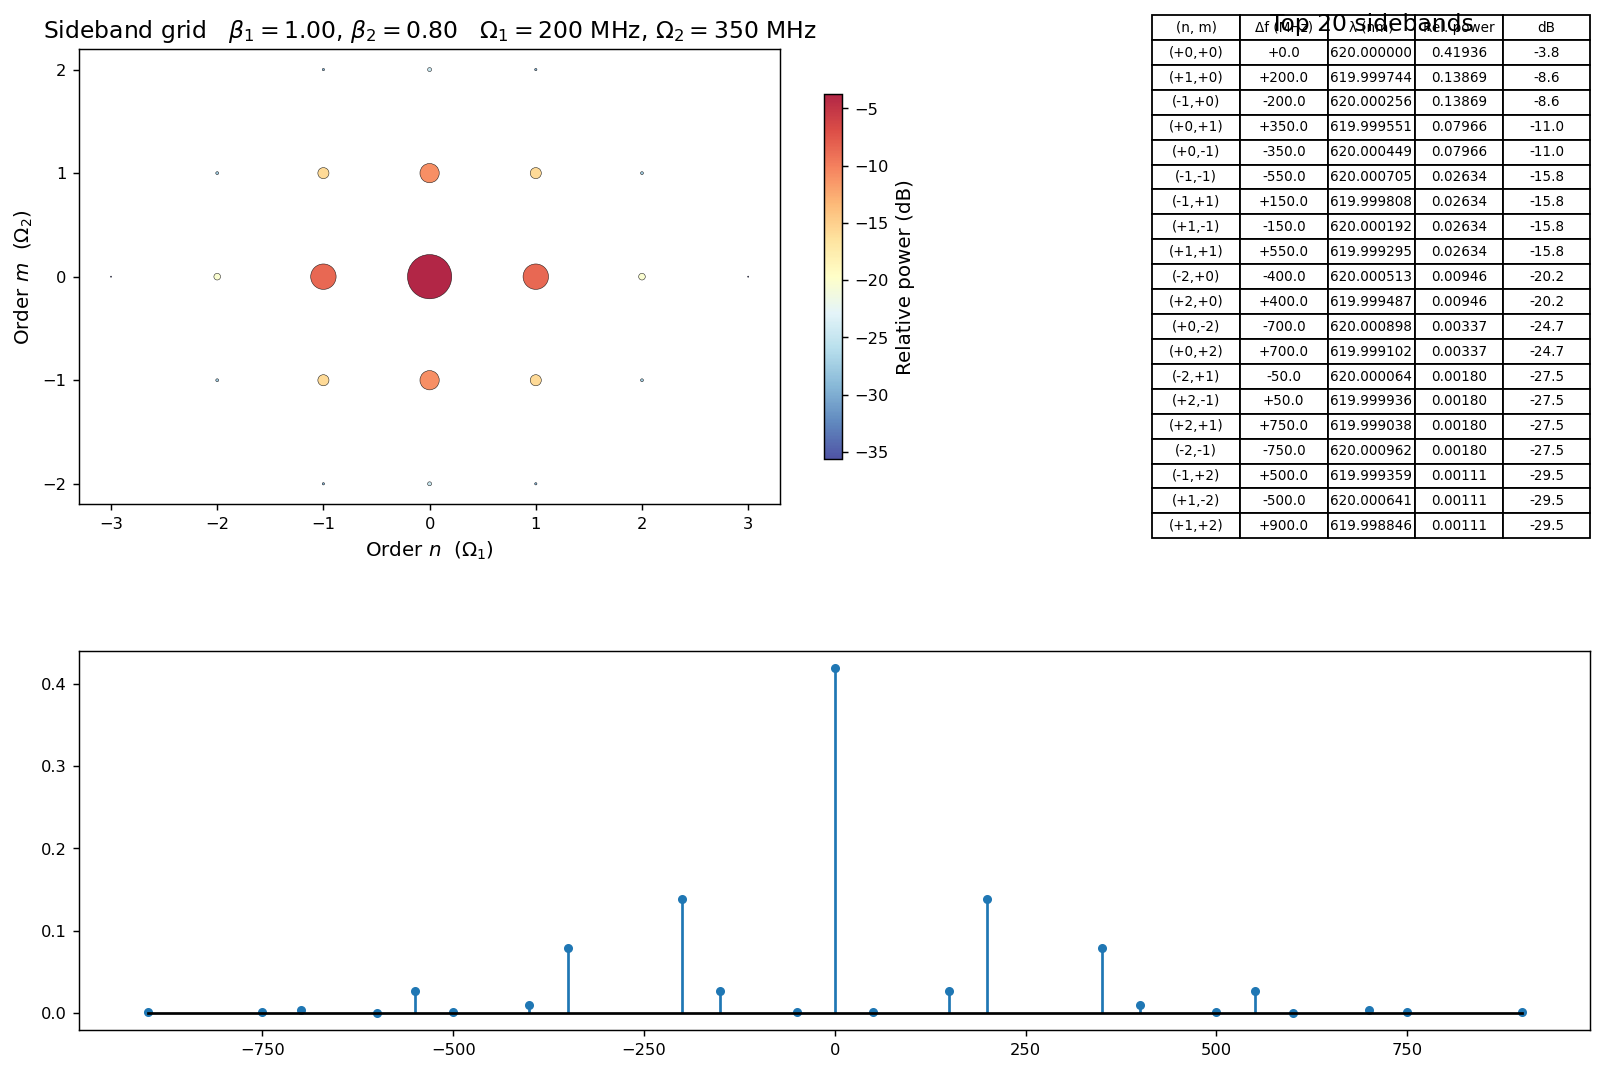

In [8]:
def plot_two_freq_spectrum(Omega1_MHz, Omega2_MHz, beta1, beta2,
                           n_max=6, power_floor_dB=-40):
    """
    Visualise the sideband structure for two-tone EOM modulation.
    """
    orders = np.arange(-n_max, n_max + 1)
    J1 = besselJ(orders, beta1)
    J2 = besselJ(orders, beta2)

    ns, ms = np.meshgrid(orders, orders, indexing="ij")
    J1_grid, J2_grid = np.meshgrid(J1, J2, indexing="ij")
    power_grid = (J1_grid ** 2) * (J2_grid ** 2)
    freq_grid = ns * Omega1_MHz + ms * Omega2_MHz   # MHz offset

    mask = 10 * np.log10(np.maximum(power_grid, 1e-30)) >= power_floor_dB

    ns_f = ns[mask]
    ms_f = ms[mask]
    freqs_f = freq_grid[mask]
    powers_f = power_grid[mask]

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], width_ratios=[2, 1],
                          hspace=0.35, wspace=0.30)

    # ── Top-left: 2D bubble chart (n vs m) ──
    ax_bub = fig.add_subplot(gs[0, 0])
    sizes = powers_f / powers_f.max() * 600
    sc = ax_bub.scatter(ns_f, ms_f, s=sizes, c=10*np.log10(np.maximum(powers_f, 1e-30)),
                        cmap="RdYlBu_r", edgecolors="k", linewidths=0.3, alpha=0.85)
    ax_bub.set_xlabel(rf"Order $n$  ($\Omega_1$)")
    ax_bub.set_ylabel(rf"Order $m$  ($\Omega_2$)")
    ax_bub.set_title(rf"Sideband grid   $\beta_1={beta1:.2f}$, $\beta_2={beta2:.2f}$"
                     rf"   $\Omega_1={Omega1_MHz}$ MHz, $\Omega_2={Omega2_MHz}$ MHz")
    ax_bub.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax_bub.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    cb = fig.colorbar(sc, ax=ax_bub, shrink=0.8, label="Relative power (dB)")

    # ── Top-right: table of strongest sidebands ──
    ax_tbl = fig.add_subplot(gs[0, 1])
    ax_tbl.axis("off")
    sort_idx = np.argsort(-powers_f)[:20]
    table_data = []
    for idx in sort_idx:
        n, m, f, p = ns_f[idx], ms_f[idx], freqs_f[idx], powers_f[idx]
        wl_nm = c / (nu_carrier + f * 1e6) * 1e9
        table_data.append([
            f"({n:+d},{m:+d})",
            f"{f:+.1f}",
            f"{wl_nm:.6f}",
            f"{p:.5f}",
            f"{10*np.log10(max(p,1e-30)):+.1f}",
        ])
    col_labels = ["(n, m)", "Δf (MHz)", "λ (nm)", "Rel. power", "dB"]
    tbl = ax_tbl.table(cellText=table_data, colLabels=col_labels,
                       loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.scale(1.0, 1.15)
    ax_tbl.set_title("Top 20 sidebands", pad=10)

    # ── Bottom: collapsed 1-D spectrum ──
    ax_sp = fig.add_subplot(gs[1, :])

    unique_freqs = {}
    for f, p in zip(freq_grid.ravel(), power_grid.ravel()):
        key = round(f, 4)
        unique_freqs[key] = unique_freqs.get(key, 0) + p

    freqs_1d = np.array(sorted(unique_freqs.keys()))
    powers_1d = np.array([unique_freqs[f] for f in freqs_1d])
    mask_1d = 10 * np.log10(np.maximum(powers_1d, 1e-30)) >= power_floor_dB

    colors_1d = ["#d62728" if abs(f) < 0.01 else "#1f77b4" for f in freqs_1d[mask_1d]]
    ml, sl, bl = ax_sp.stem(freqs_1d[mask_1d], powers_1d[mask_1d],
                            linefmt="-", markerfmt="o", basefmt="k-")
    ml.set_markersize(4)
    sl.set_colors(colors_1d)

    ax_sp.set_xlabel("Frequency offset from carrier (MHz)")
    ax_sp.set_ylabel("Total relative power")
    ax_sp.set_title("Collapsed 1-D optical spectrum (degenerate sidebands summed)")
    ax_sp.set_ylim(bottom=0)

    plt.show()

    print(f"Total visible components: {mask.sum()}")
    print(f"Total power (all orders): {power_grid.sum():.5f}")


# ── Example: two-tone modulation ──
plot_two_freq_spectrum(Omega1_MHz=200, Omega2_MHz=350,
                       beta1=1.0, beta2=0.8)

## 3. Interactive explorer

Use the sliders below to change the modulation index and RF frequency in real time and watch the spectrum update.

> **Requires `ipywidgets`.** Install with `pip install ipywidgets` if needed.

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='β (rad)', max=5.0, min=0.01…

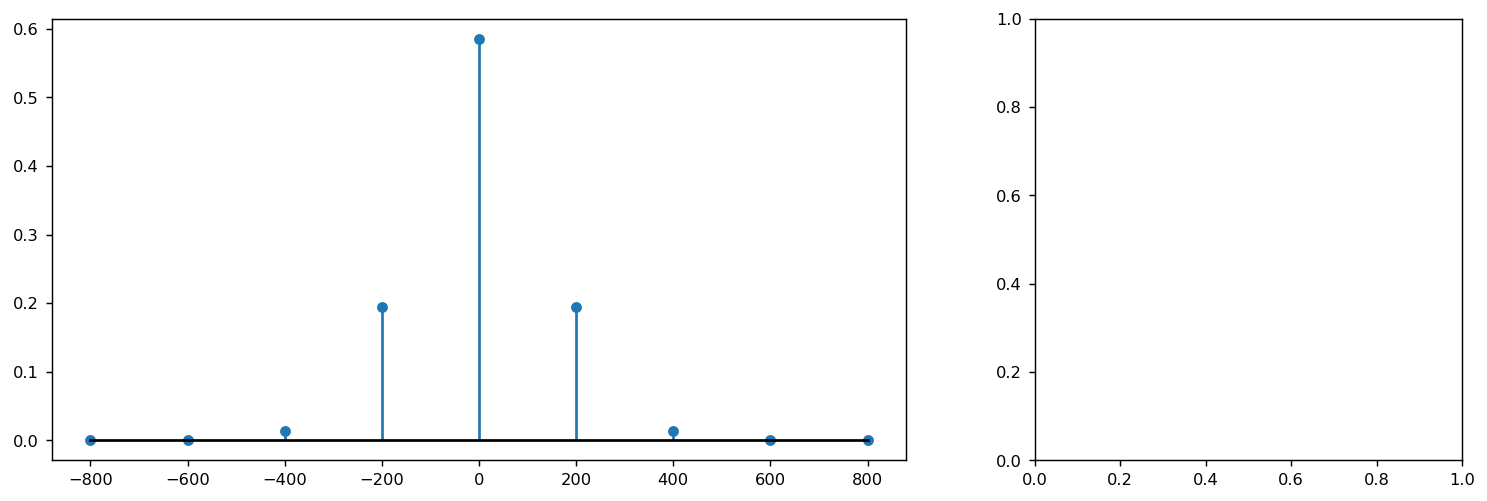

In [9]:
from ipywidgets import interact, FloatSlider, IntSlider

@interact(
    beta=FloatSlider(value=1.0, min=0.01, max=5.0, step=0.05,
                     description="β (rad)", continuous_update=False),
    Omega_MHz=FloatSlider(value=200, min=10, max=2000, step=10,
                          description="Ω/2π (MHz)", continuous_update=False),
    n_max=IntSlider(value=10, min=3, max=20, description="n_max"),
)
def interactive_single(beta, Omega_MHz, n_max):
    plot_single_freq_spectrum(Omega_MHz, beta, n_max=n_max)

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='β₁', max=4.0, min=0.01, ste…

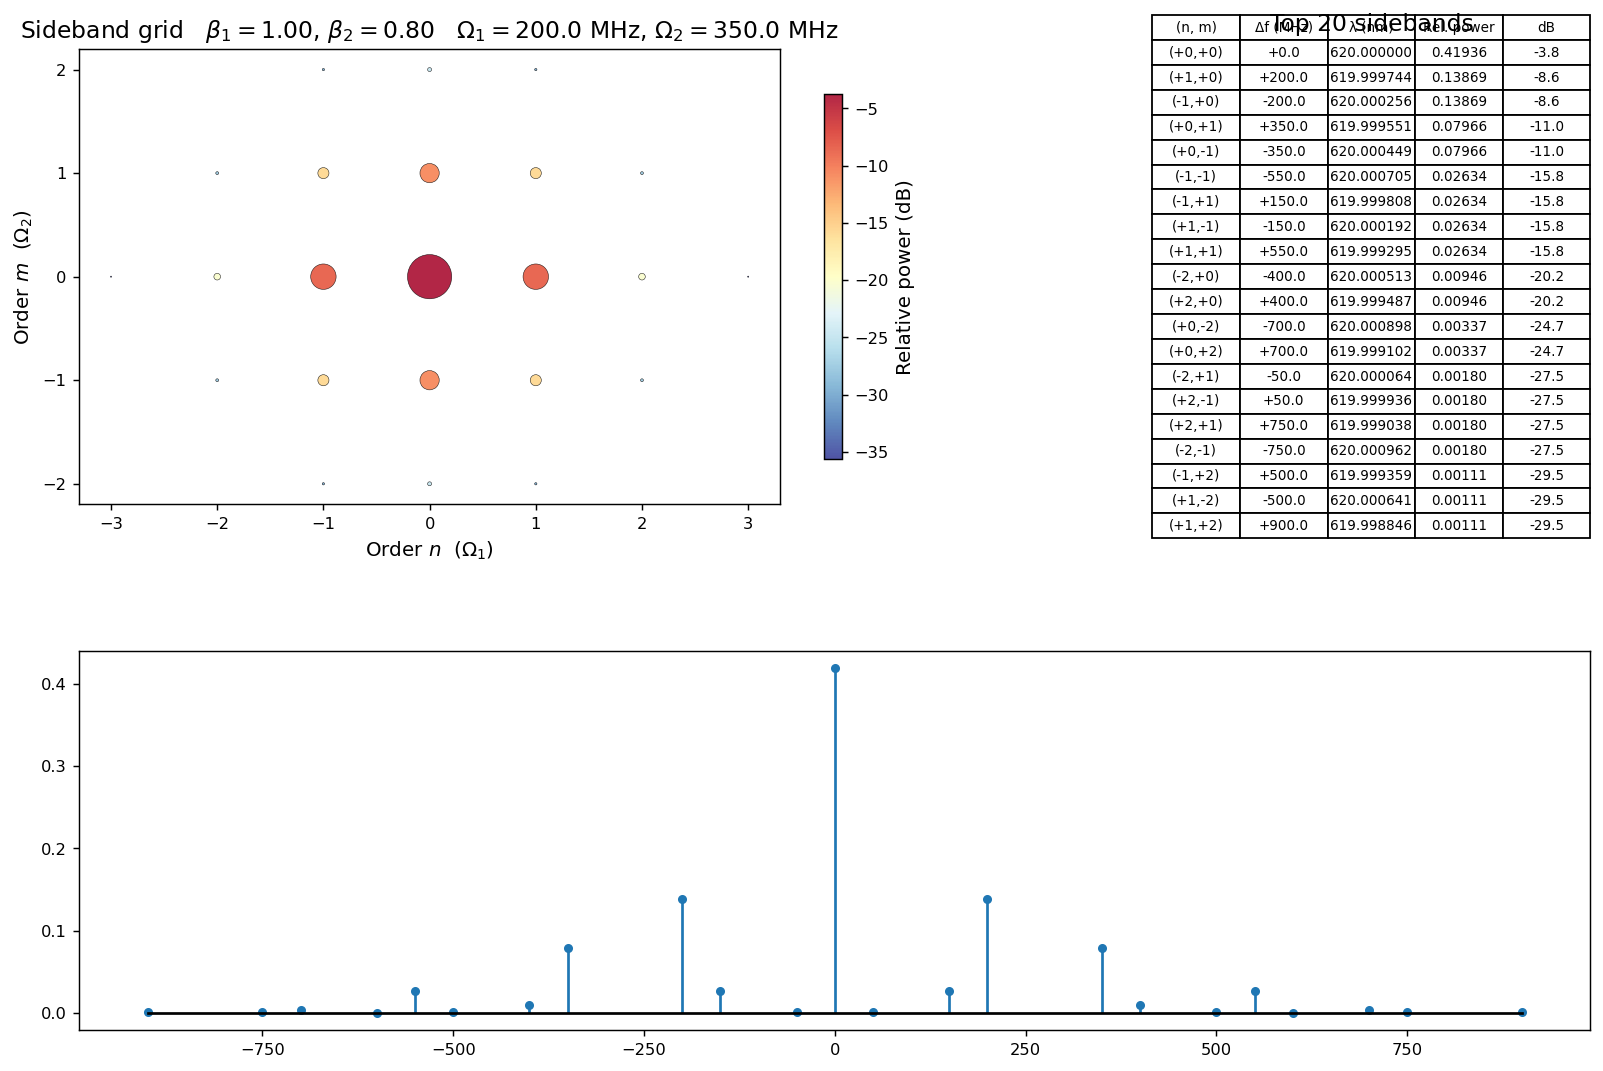

In [10]:
@interact(
    beta1=FloatSlider(value=1.0, min=0.01, max=4.0, step=0.05,
                      description="β₁", continuous_update=False),
    beta2=FloatSlider(value=0.8, min=0.01, max=4.0, step=0.05,
                      description="β₂", continuous_update=False),
    Omega1_MHz=FloatSlider(value=200, min=10, max=2000, step=10,
                           description="Ω₁ (MHz)", continuous_update=False),
    Omega2_MHz=FloatSlider(value=350, min=10, max=2000, step=10,
                           description="Ω₂ (MHz)", continuous_update=False),
    n_max=IntSlider(value=6, min=2, max=12, description="n_max"),
)
def interactive_two_tone(beta1, beta2, Omega1_MHz, Omega2_MHz, n_max):
    plot_two_freq_spectrum(Omega1_MHz, Omega2_MHz, beta1, beta2, n_max=n_max)

## 4. Bessel function reference

Quick look at how $J_n(\beta)$ and $J_n^2(\beta)$ behave — the key to understanding EOM spectra.

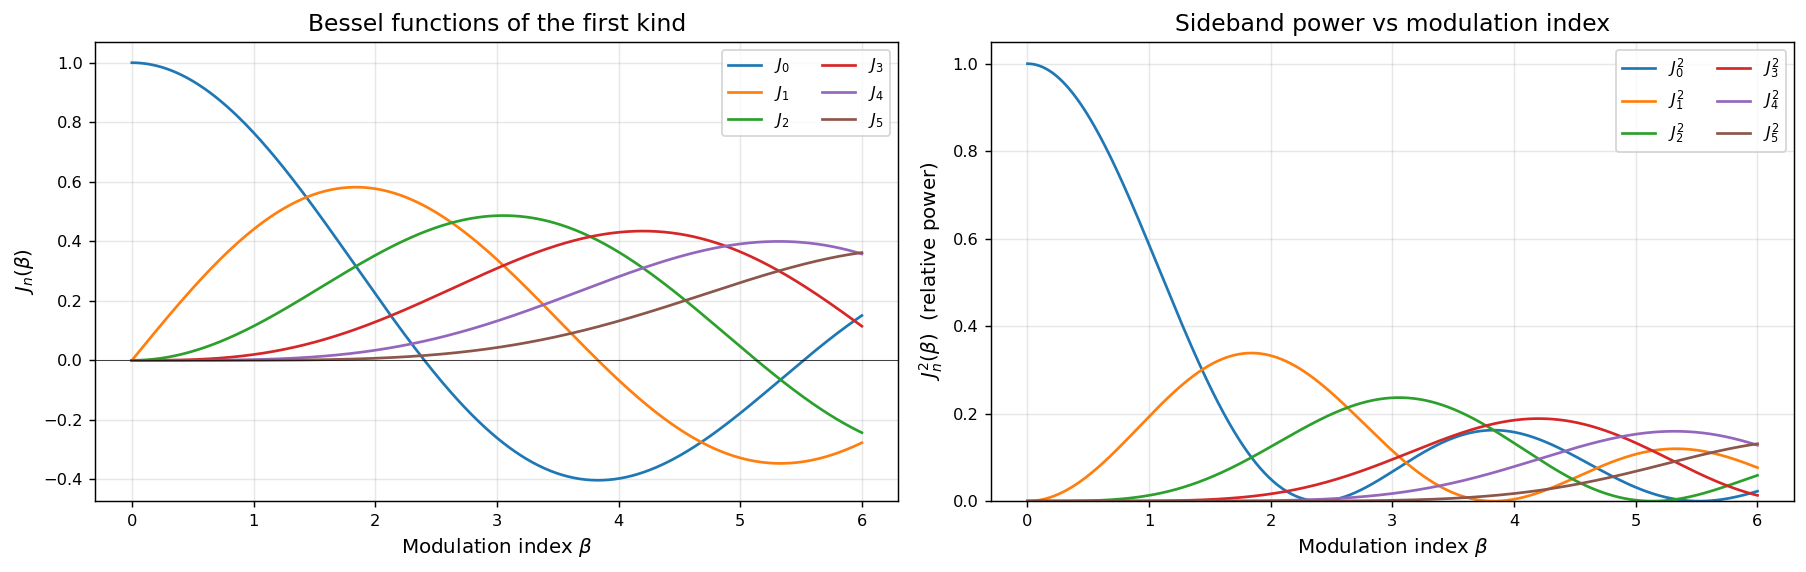

Key observations:
  • At β ≈ 2.405 the carrier J₀(β) = 0  →  all power is in sidebands
  • For β ≪ 1 only the ±1 sidebands are significant (small-signal regime)
  • Σ Jₙ²(β) = 1  for all β  (power conservation)


In [11]:
beta_arr = np.linspace(0, 6, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

for n in range(6):
    jn = besselJ(n, beta_arr)
    ax1.plot(beta_arr, jn, label=f"$J_{n}$")
    ax2.plot(beta_arr, jn ** 2, label=rf"$J_{n}^2$")

ax1.set_xlabel(r"Modulation index $\beta$")
ax1.set_ylabel(r"$J_n(\beta)$")
ax1.set_title("Bessel functions of the first kind")
ax1.legend(ncol=2)
ax1.axhline(0, color="k", lw=0.4)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel(r"Modulation index $\beta$")
ax2.set_ylabel(r"$J_n^2(\beta)$  (relative power)")
ax2.set_title("Sideband power vs modulation index")
ax2.legend(ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

print("Key observations:")
print("  • At β ≈ 2.405 the carrier J₀(β) = 0  →  all power is in sidebands")
print("  • For β ≪ 1 only the ±1 sidebands are significant (small-signal regime)")
print("  • Σ Jₙ²(β) = 1  for all β  (power conservation)")